## ДЗ №1. Метрики и простейшие алгоритмы рекомендаций

## Общая информация
**Дата выдачи: 24 января 2025**

**Дедлайн: 8 февраля 2025 23:59 MSK**

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from tqdm.auto import tqdm
from typing import List, Optional
from metric_tests import run_tests

%matplotlib inline

## О задании

В этой работе мы посмотрим на то, как работают самые простые модели для рекомендаций. Как правило, они не требуют построения специальных моделей, но даже так оказываются полезны в качестве бейзлайна. Попробуем сделать предсказания с помощью EASE. Это тоже довольно простой подход, но не стоит забывать, что сложные модели могут оказаться не лучшим выбором в условиях большого количества данных. Посчитаем метрики, построим графики и подумаем, насколько хорошо эти модели вообще решают поставленную задачу.

Мы будем работать с датасетом по рекомендации фильмов от Kion MTS, который был дан для соревнования. Сперва нужно его предобработать, эта часть повторяет то, что было на семинаре.

Датасет необходимо скачать: https://ods.ai/competitions/competition-recsys-21/data

Оттуда нужны файлы `interactions.csv` и `items.csv`

Каждое задание весит **1 балл**, если выполнено полностью и без ошибок, **0 баллов** ставится при наличии хотя бы 1 ошибки. Максимальная оценка - **10 баллов**. Шаблоны функций и классов можно менять по своему усмотрению.

In [32]:
df = pd.read_csv('interactions.csv').iloc[:-1]
df.head()

,user_id,item_id,last_watch_dt,total_dur,watched_pct
0,176549,9506,2021-05-11,4250,72.0
1,699317,1659,2021-05-29,8317,100.0
2,656683,7107,2021-05-09,10,0.0
3,864613,7638,2021-07-05,14483,100.0
4,964868,9506,2021-04-30,6725,100.0


In [33]:
df['last_watch_dt'] = (pd.to_datetime(df['last_watch_dt']) - pd.to_datetime(df['last_watch_dt']).min())
df['last_watch_dt'] = df.last_watch_dt.apply(lambda x: int(str(x).split()[0]))
df.sample(5)

,user_id,item_id,last_watch_dt,total_dur,watched_pct
2846336,846943,2657,149,2406,33.0
3782893,221652,13410,38,4161,86.0
5282659,924353,8391,125,542,9.0
3864399,712436,13787,104,321,6.0
1034159,790729,14245,142,5751,100.0


Сделаем разбиение по времени

<Axes: >

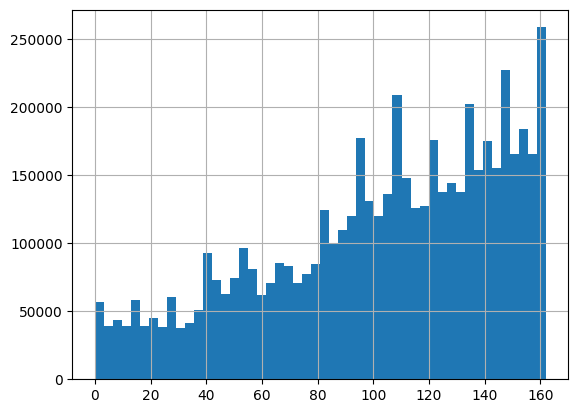

In [34]:
df.last_watch_dt.hist(bins=50)

In [35]:
train_df = df.loc[(df.last_watch_dt < 160-7)].copy()
test_df = df.loc[(df.last_watch_dt >= 160-7)].copy()

train_users = train_df.user_id.unique()
test_users = test_df.user_id.unique()

all_included = np.intersect1d(train_users, test_users)

print('число людей и там и там: ', all_included.shape[0])
print('число людей всего:', train_users.shape[0])

число людей и там и там:  134670
число людей всего: 880449


In [36]:
len(set(test_users) - set(train_users)) / len(test_users)

0.37768022181146027

И переведём всё к соединённому датасету:

In [37]:
n_users = 10000

all_included = np.random.choice(all_included, size=n_users, replace=False)

train_df = train_df.loc[train_df.user_id.isin(all_included)].copy()
test_df = test_df.loc[test_df.user_id.isin(all_included)].copy()

assert train_df.last_watch_dt.max() < test_df.last_watch_dt.min()
assert train_df.user_id.nunique() == n_users
assert test_df.user_id.nunique() == n_users

In [38]:
train_df.head()

,user_id,item_id,last_watch_dt,total_dur,watched_pct
247,284039,9728,122,604,9.0
406,845119,598,122,184,4.0
459,384198,13865,93,6369,100.0
474,920879,8430,37,1395,16.0
485,905557,12501,136,72571,100.0


In [39]:
train_grouped = train_df.groupby('user_id').apply(
    lambda x: [(t1, t2) for t1, t2 in sorted(zip(x.item_id,
                                                 x.last_watch_dt), key=lambda x: x[1])]
).reset_index()
train_grouped.rename({0:'train_interactions'}, axis=1, inplace=True)

test_grouped = test_df.groupby('user_id').apply(
    lambda x: [(t1, t2) for t1, t2 in sorted(zip(x.item_id,
                                                         x.last_watch_dt), key=lambda x: x[1])]
).reset_index()
test_grouped.rename({0:'test_interactions'}, axis=1, inplace=True)

train_grouped.head()

/tmp/ipython-input-1105526701.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  train_grouped = train_df.groupby('user_id').apply(
/tmp/ipython-input-1105526701.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  test_grouped = test_df.groupby('user_id').apply(


,user_id,train_interactions
0,55,"[(9896, 15), (6192, 60), (3076, 99), (15297, 1..."
1,120,"[(15297, 151), (6809, 151), (1000, 151)]"
2,241,"[(5051, 9), (2134, 9), (13913, 112), (6646, 11..."
3,313,"[(14170, 4), (162, 4), (8276, 6), (758, 14), (..."
4,315,"[(3792, 58), (11697, 58), (8636, 78), (9070, 8..."


In [10]:
joined = train_grouped.merge(test_grouped)
joined.head()

,user_id,train_interactions,test_interactions
0,75,"[(11237, 20)]","[(4151, 158), (15297, 158)]"
1,106,"[(312, 35), (3182, 58), (4718, 78), (6809, 87)...","[(14619, 162)]"
2,304,"[(11985, 71), (4457, 99), (9728, 125)]","[(6054, 161)]"
3,522,"[(12501, 14), (2424, 15), (12254, 15)]","[(11756, 155), (4201, 159), (11899, 159)]"
4,537,"[(9728, 127)]","[(5732, 157)]"


In [40]:
np.random.seed(777)

class Random:

    def __init__(self):

        self.trained = False

    def fit(self, df, col='train_interactions'):

        items = set()
        for _, row in df.iterrows():
            for item, _ in row[col]:
                items.add(item)

        self.items = list(items)
        self.trained = True

    def predict(self, df, topn=10):
        assert self.trained
        return [np.random.choice(self.items, replace=False, size=topn)]*len(df)


random = Random()
random.fit(joined)

joined['random_recs'] = random.predict(joined, topn=3)
joined.head()

,user_id,train_interactions,test_interactions,random_recs,toppopular_recs,toppop_w1_recs,toppop_w2_recs,toppop_w3_recs,toppop_w4_recs,toppop_w5_recs,...,toppop_w7_recs,toppop_w8_recs,toppop_w9_recs,toppop_w10_recs,toppop_w11_recs,toppop_w12_recs,toppop_w13_recs,toppop_w14_recs,toppop_w15_recs,toppopular_recs_100
0,75,"[(11237, 20)]","[(4151, 158), (15297, 158)]","[10029, 8821, 1068]","[10440, 9728, 15297, 13865, 3734, 4151, 4880, ...","[10440, 15297, 9728, 13865, 4151, 3734, 12192,...","[10440, 15297, 9728, 13865, 4151, 3734, 12192,...","[10440, 15297, 9728, 13865, 3734, 4151, 12192,...","[10440, 15297, 9728, 13865, 3734, 4151, 12192,...","[10440, 15297, 9728, 13865, 3734, 4151, 2657, ...",...,"[10440, 9728, 15297, 13865, 3734, 4151, 2657, ...","[10440, 9728, 15297, 13865, 3734, 4151, 2657, ...","[10440, 9728, 15297, 13865, 3734, 4151, 2657, ...","[10440, 9728, 15297, 13865, 3734, 4151, 2657, ...","[10440, 9728, 15297, 13865, 3734, 4151, 2657, ...","[10440, 9728, 15297, 13865, 3734, 4151, 2657, ...","[10440, 9728, 15297, 13865, 3734, 4151, 2657, ...","[10440, 9728, 15297, 13865, 3734, 4151, 2657, ...","[10440, 9728, 15297, 13865, 3734, 4151, 2657, ...","[10440, 9728, 15297, 13865, 3734, 4151, 4880, ..."
1,106,"[(312, 35), (3182, 58), (4718, 78), (6809, 87)...","[(14619, 162)]","[10029, 8821, 1068]","[10440, 9728, 15297, 13865, 3734, 4151, 4880, ...","[10440, 15297, 9728, 13865, 4151, 3734, 12192,...","[10440, 15297, 9728, 13865, 4151, 3734, 12192,...","[10440, 15297, 9728, 13865, 3734, 4151, 12192,...","[10440, 15297, 9728, 13865, 3734, 4151, 12192,...","[10440, 15297, 9728, 13865, 3734, 4151, 2657, ...",...,"[10440, 9728, 15297, 13865, 3734, 4151, 2657, ...","[10440, 9728, 15297, 13865, 3734, 4151, 2657, ...","[10440, 9728, 15297, 13865, 3734, 4151, 2657, ...","[10440, 9728, 15297, 13865, 3734, 4151, 2657, ...","[10440, 9728, 15297, 13865, 3734, 4151, 2657, ...","[10440, 9728, 15297, 13865, 3734, 4151, 2657, ...","[10440, 9728, 15297, 13865, 3734, 4151, 2657, ...","[10440, 9728, 15297, 13865, 3734, 4151, 2657, ...","[10440, 9728, 15297, 13865, 3734, 4151, 2657, ...","[10440, 9728, 15297, 13865, 3734, 4151, 4880, ..."
2,304,"[(11985, 71), (4457, 99), (9728, 125)]","[(6054, 161)]","[10029, 8821, 1068]","[10440, 9728, 15297, 13865, 3734, 4151, 4880, ...","[10440, 15297, 9728, 13865, 4151, 3734, 12192,...","[10440, 15297, 9728, 13865, 4151, 3734, 12192,...","[10440, 15297, 9728, 13865, 3734, 4151, 12192,...","[10440, 15297, 9728, 13865, 3734, 4151, 12192,...","[10440, 15297, 9728, 13865, 3734, 4151, 2657, ...",...,"[10440, 9728, 15297, 13865, 3734, 4151, 2657, ...","[10440, 9728, 15297, 13865, 3734, 4151, 2657, ...","[10440, 9728, 15297, 13865, 3734, 4151, 2657, ...","[10440, 9728, 15297, 13865, 3734, 4151, 2657, ...","[10440, 9728, 15297, 13865, 3734, 4151, 2657, ...","[10440, 9728, 15297, 13865, 3734, 4151, 2657, ...","[10440, 9728, 15297, 13865, 3734, 4151, 2657, ...","[10440, 9728, 15297, 13865, 3734, 4151, 2657, ...","[10440, 9728, 15297, 13865, 3734, 4151, 2657, ...","[10440, 9728, 15297, 13865, 3734, 4151, 4880, ..."
3,522,"[(12501, 14), (2424, 15), (12254, 15)]","[(11756, 155), (4201, 159), (11899, 159)]","[10029, 8821, 1068]","[10440, 9728, 15297, 13865, 3734, 4151, 4880, ...","[10440, 15297, 9728, 13865, 4151, 3734, 12192,...","[10440, 15297, 9728, 13865, 4151, 3734, 12192,...","[10440, 15297, 9728, 13865, 3734, 4151, 12192,...","[10440, 15297, 9728, 13865, 3734, 4151, 12192,...","[10440, 15297, 9728, 13865, 3734, 4151, 2657, ...",...,"[10440, 9728, 15297, 13865, 3734, 4151, 2657, ...","[10440, 9728, 15297, 13865, 3734, 4151, 2657, ...","[10440, 9728, 15297, 13865, 3734, 4151, 2657, ...","[10440, 9728, 15297, 13865, 3734, 4151, 2657, ...","[10440, 9728, 15297, 13865, 3734, 4151, 2657, ...","[10440, 9728, 15297, 13865, 3734, 4151, 2657, ...","[10440, 9728, 15297, 13865, 3734, 4151, 2657, ...","[10440, 9728, 15297, 13865, 3734, 4151, 2657, ...","[10440, 9728, 15297, 13865, 3734, 4151, 2657, ...","[10440, 9728, 15297, 1386

**Задание №1. Метрики и бейзлайны**

Добавьте реализацию метрик AP, RR, HR, их усреднённые версии по $U$ мы посчитаем ниже. За имплементацию с циклами балл будет снижаться, векторизуйте! ( ͡° ͜ʖ ͡°)

$$
AP_u@k = \frac{1}{\min(k, n_u)} \sum_{i=1}^k r_u(i) p_u@i
$$
$$
p_u@k = \dfrac{1}{k}\sum_{j=1}^k r_u(j)
$$
$$
RR@k = \dfrac{1}{\text{rank}_i@k}
$$
$$
HR@k = [\exists \ y_i = 1 \ \text{among k preds}]
$$


*   $n_u$ - число айтемов, с которыми взаимодействовал юзер $u$
*   $y_i$ - релевантно ли $i$-ое предсказание, $y_i \in \{0,1\}$
* $\text{rank}_i@k$ - позиция первого релеваннтого айтема среди первых $k$ предсказаний
* HR@k - среди первых $k$ предсказаний есть хотя бы одно релевантное

Считайте, что если `topn` не задано, то берётся всегда $n_u$.

In [12]:
def ap_metric(
    gt_items: List[int],
    predictions: List[int],
    topn: Optional[int]=None
)-> float:
    gt_set = set(gt_items)
    nu = len(gt_set)
    if nu == 0:
        return 0.0
    if topn is None:
        k = len(predictions)
    else:
        k = min(topn, len(predictions))
    if k == 0:
        return 0.0
    top_preds = np.array(predictions[:k])
    relevant = np.array([p in gt_set for p in top_preds], dtype=float)
    positions = np.arange(1, k + 1, dtype=float)
    precisions = np.cumsum(relevant) / positions
    sum_precision = np.sum(relevant*precisions)
    if np.sum(relevant) == 0:
        return 0.0

    return sum_precision/min(k, nu)

def rr_metric(
    gt_items: List[int],
    predictions: List[int],
    topn: Optional[int]=None
) -> float:
    gt_set = set(gt_items)
    if topn is None:
        k = len(predictions)
    else:
        k = min(topn, len(predictions))
    relevant = np.array([p in gt_set for p in predictions[:k]], dtype=bool)
    first_hit_idx = np.argmax(relevant)
    if relevant[first_hit_idx]:
        return 1.0 / (first_hit_idx + 1)
    return 0.0


def hr_metric(
    gt_items: List[int],
    predictions: List[int],
    topn: Optional[int]=None
) -> bool:
    gt_set = set(gt_items)
    if topn is None:
        k = len(predictions)
    else:
        k = min(topn, len(predictions))
    relevant = np.array([p in gt_set for p in predictions[:k]], dtype=bool)
    return 1.0 if np.any(relevant) else 0.0


Для вашего удобства в файле `metric_tests.py` есть тесты, но хардкодить их, разумеется, не стоит.

In [41]:
run_tests(ap_metric, rr_metric, hr_metric)

В следующей ячейке код, который считает и усредняет метрики по юзерам. Он взят с семинара, при желании можно его тоже модифицировать, например, векторизовать.

In [14]:
def evaluate_recommender(df, model_preds, gt_col='test_interactions'):

    metric_values = []

    for idx, row in df.iterrows():
        gt_items = [x[0] for x in row[gt_col]]
        predictions = row[model_preds]

        ap = ap_metric(gt_items, predictions)
        rr = rr_metric(gt_items, predictions)
        hr = hr_metric(gt_items, predictions)

        metric_values.append((ap, rr, hr))

    return {'map': np.mean([x[0] for x in metric_values]),
            'mrr': np.mean([x[1] for x in metric_values]),
            'hr': np.mean([x[2] for x in metric_values])}

Если вы всё сделали правильно, рандомные предсказания должны дать хоть какое-то качество, но не очень большое.

In [15]:
evaluate_recommender(joined, model_preds='random_recs')

{'map': np.float64(0.00039999999999999996),
 'mrr': np.float64(0.0008),
 'hr': np.float64(0.0016)}

In [16]:
class TopPopular:

    def __init__(self):

        self.trained = False

    def fit(self, df, col='train_interactions'):

        counts = {}
        for _, row in df.iterrows():
            for item, _ in row[col]:
                if item in counts:
                    counts[item] += 1
                else:
                    counts[item] = 1

        counts = sorted(counts.items(), key=lambda x: x[1], reverse=True)

        self.recommenations = [x[0] for x in counts]
        self.trained = True

    def predict(self, df, topn=10)  -> List[np.ndarray]:

        assert self.trained
        return [self.recommenations[:topn]]*len(df)


toppop = TopPopular()
toppop.fit(joined)

joined['toppopular_recs'] = toppop.predict(joined)
joined.head()

,user_id,train_interactions,test_interactions,random_recs,toppopular_recs
0,75,"[(11237, 20)]","[(4151, 158), (15297, 158)]","[10029, 8821, 1068]","[10440, 9728, 15297, 13865, 3734, 4151, 4880, ..."
1,106,"[(312, 35), (3182, 58), (4718, 78), (6809, 87)...","[(14619, 162)]","[10029, 8821, 1068]","[10440, 9728, 15297, 13865, 3734, 4151, 4880, ..."
2,304,"[(11985, 71), (4457, 99), (9728, 125)]","[(6054, 161)]","[10029, 8821, 1068]","[10440, 9728, 15297, 13865, 3734, 4151, 4880, ..."
3,522,"[(12501, 14), (2424, 15), (12254, 15)]","[(11756, 155), (4201, 159), (11899, 159)]","[10029, 8821, 1068]","[10440, 9728, 15297, 13865, 3734, 4151, 4880, ..."
4,537,"[(9728, 127)]","[(5732, 157)]","[10029, 8821, 1068]","[10440, 9728, 15297, 13865, 3734, 4151, 4880, ..."


Самые популярные предсказания должны показать более высокое качество.

In [43]:
evaluate_recommender(joined, model_preds='toppopular_recs')

{'map': np.float64(0.05336965810027715),
 'mrr': np.float64(0.0782238492063492),
 'hr': np.float64(0.2091)}

**Задание №2. Рекомендации в окне**

Здесь необходимо переделать метод рекомендации по популярности так, что популярность считается только за какое-то более свежее временное окно. Под окном подразумевается какой-то временной промежуток, например, ближайший месяц. Соответственно, всё что за его пределами, не учитывается.

In [18]:
class TopPopularWeighted(TopPopular):

    def __init__(self, min_window=2):
        super().__init__()
        self.min_window = min_window

    def fit(self, df, col='train_interactions'):
        counts = {}
        for _, row in df.iterrows():
            recent_interactions = row[col][-self.min_window:]
            for item, _ in recent_interactions:
                if item in counts:
                    counts[item] += 1
                else:
                    counts[item] = 1

        counts = sorted(counts.items(), key=lambda x: x[1], reverse=True)
        self.recommenations = [x[0] for x in counts]
        self.trained = True


Теперь постройте графики зависимости значений трёх метрик (AP@k, RR@k, HR@k) от размера окна.

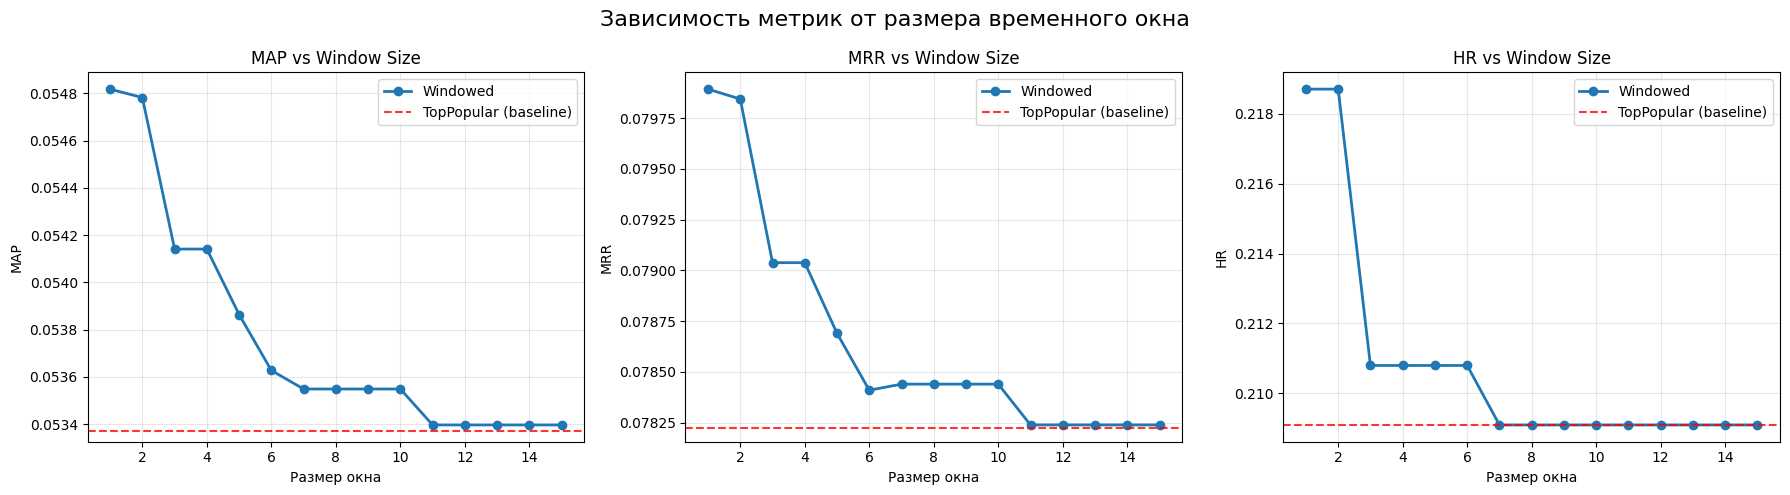

In [44]:
baseline_metrics = evaluate_recommender(joined, 'toppopular_recs')
window_sizes = range(1, 16)
results = {'map': [], 'mrr': [], 'hr': []}

for window_size in window_sizes:
    model = TopPopularWeighted(min_window=window_size)
    model.fit(joined, col='train_interactions')

    recs = model.predict(joined)
    col_name = f'toppop_w{window_size}_recs'
    joined[col_name] = recs

    metrics = evaluate_recommender(joined, col_name)

    results['map'].append(metrics['map'])
    results['mrr'].append(metrics['mrr'])
    results['hr'].append(metrics['hr'])

# графики
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics_names = ['MAP', 'MRR', 'HR']
data = [results['map'], results['mrr'], results['hr']]

for i, (metric_data, name) in enumerate(zip(data, metrics_names)):
    axes[i].plot(window_sizes, metric_data, 'o-', linewidth=2, markersize=6, label='Windowed')

    baseline_val = baseline_metrics['map'] if 'MAP' in name else \
                   baseline_metrics['mrr'] if 'MRR' in name else \
                   baseline_metrics['hr']

    axes[i].axhline(y=baseline_val, color='red', linestyle='--',
                   alpha=0.8, label=f'TopPopular (baseline)')

    axes[i].set_xlabel('Размер окна')
    axes[i].set_ylabel(name)
    axes[i].grid(True, alpha=0.3)
    axes[i].legend()
    axes[i].set_title(f'{name} vs Window Size')

plt.suptitle('Зависимость метрик от размера временного окна', fontsize=16)
plt.tight_layout()
plt.show()


In [20]:
print(f"Базовый TopPopular: MAP={baseline_metrics['map']:.4f}, MRR={baseline_metrics['mrr']:.4f}, HR={baseline_metrics['hr']:.4f}")

results_df = pd.DataFrame({
    'Window': list(window_sizes),
    'MAP': results['map'],
    'MRR': results['mrr'],
    'HR': results['hr'],
})

print(results_df.round(4))

Базовый TopPopular: MAP=0.0534, MRR=0.0782, HR=0.2091
    Window     MAP     MRR      HR
0        1  0.0548  0.0799  0.2187
1        2  0.0548  0.0798  0.2187
2        3  0.0541  0.0790  0.2108
3        4  0.0541  0.0790  0.2108
4        5  0.0539  0.0787  0.2108
5        6  0.0536  0.0784  0.2108
6        7  0.0535  0.0784  0.2091
7        8  0.0535  0.0784  0.2091
8        9  0.0535  0.0784  0.2091
9       10  0.0535  0.0784  0.2091
10      11  0.0534  0.0782  0.2091
11      12  0.0534  0.0782  0.2091
12      13  0.0534  0.0782  0.2091
13      14  0.0534  0.0782  0.2091
14      15  0.0534  0.0782  0.2091


Подумайте и ответьте, как размер окна влияет на качество рекомендаций. Какое значение наилучшее, есть ли у этого разумное объяснение?

**Ответ:**

Наилучшее качество показала модель с окном = 1.
В целом видно, что маленькие окна показывают себя лучше.  Объясняться данная тенденция может влиянием трендов, сезонностью (утро/вечер или выходные/будни), новинками или акциями (как правило новые товары или товары по акции быстро набирают популярность).

Окна больше 6 дней работают хуже, потому что происходит разбавление старыми данными, которые могли потерять свою актуальность.

**Задание №3. Метрики и k.**

Постройте зависимость значений MAP@K, MRR@K, HR@K для метода рекомендации по популярности. Возьмите какие-нибудь k, например, от 1 до 100, переберите значения и покажите на линейном графике.

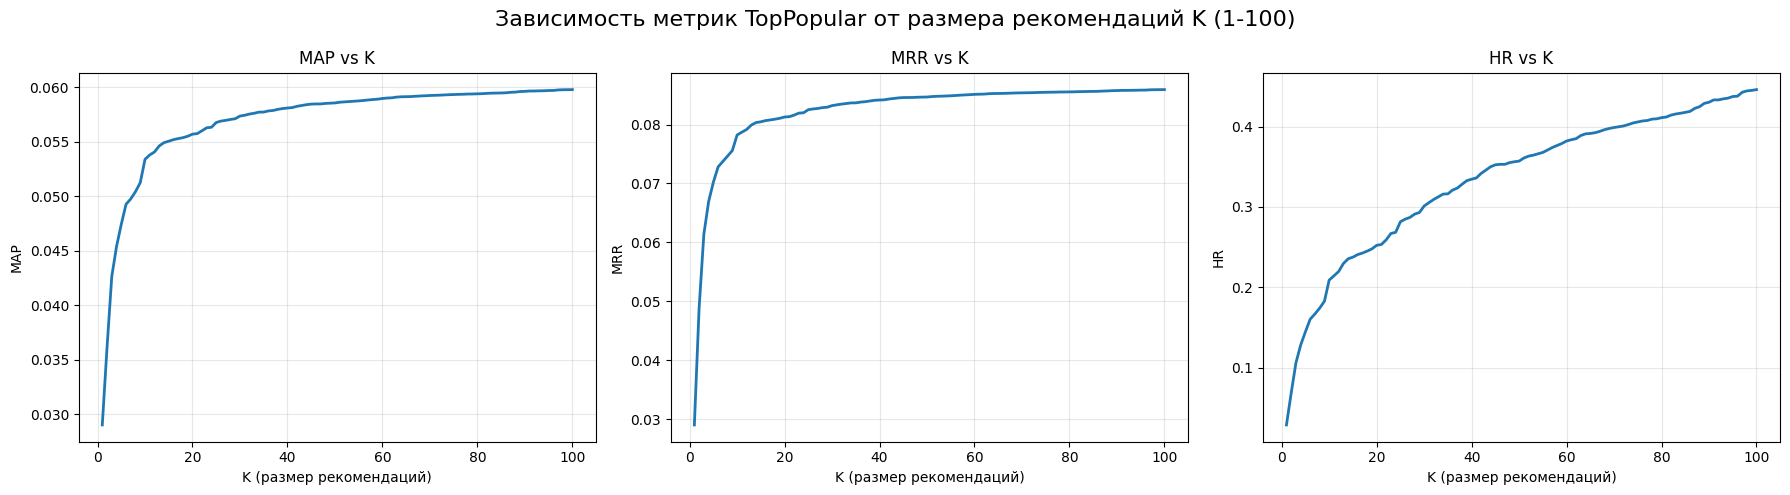

In [21]:
recs_100 = toppop.predict(joined, topn=100)
joined['toppopular_recs_100'] = recs_100

k_values = range(1, 101)
results = {'map': [], 'mrr': [], 'hr': []}

for k in k_values:
    recs_k = [r[:k] if len(r) >= k else r for r in recs_100]
    joined[f'temp_recs_k{k}'] = recs_k

    metrics = evaluate_recommender(joined, f'temp_recs_k{k}')

    results['map'].append(metrics['map'])
    results['mrr'].append(metrics['mrr'])
    results['hr'].append(metrics['hr'])

    joined.drop(f'temp_recs_k{k}', axis=1, inplace=True)


fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics_names = ['MAP', 'MRR', 'HR']
data = [results['map'], results['mrr'], results['hr']]

for i, (metric_data, name) in enumerate(zip(data, metrics_names)):
    axes[i].plot(k_values, metric_data, linewidth=2, label='TopPopular')
    axes[i].set_xlabel('K (размер рекомендаций)')
    axes[i].set_ylabel(name)
    axes[i].set_title(f'{name} vs K')
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Зависимость метрик TopPopular от размера рекомендаций K (1-100)', fontsize=16)
plt.tight_layout()
plt.show()




Хорошенько подумайте и ответьте на вопросы ниже.

3.1 Какие из метрик являются монотонными функциями по top-K? Объясните, почему они являются монотонными? \
**Ответ:**

HR — строго монотонно возрастает. По сути при увеличении K добавляются новые позиции в рассмотрение. Если релевантного не было в первых K, он может появиться в K+1. Невозможно потерять релевантный при увеличении K.

MAP — возрастает, но может достигнуть плато. Так как при увеличении K может появиться новый релевантный айтем , то добавляется слагаемое в числитель. Знаменатель min(K, nu) может увеличиться (если K < nu). В худшем случае AP(K+1) = AP (K) - тогда возникнет плато.

На получившемся графики MRR возрастает монотонно, но это не обязательно всегда будет так:
При увеличении K первый релевантный айтем может остаться на той же позиции, тогда MRR не меняется.
Может появиться на более поздней позиции и тогда MRR уменьшится.

3.2 Объясните по каждой метрике, как можно интерпретировать ее график? То есть, что можно сказать про связь изменения метрики c возможными пользовательскими сценариями, например,скроллингом ленты новостей. \
**Ответ:**

*Интерпретация HR* - Какой процент пользователей найдет хоть что-то интересное, просмотрев K рекомендаций.

Вывод по графику: Пользователям нужно просмотреть много рекомендаций, чтобы с высокой вероятностью найти что-то подходящее.

*Интерпритация MAP* - Насколько хорошо система ставит релевантные айтемы на верхние позиции.

Вывод по графику: Пользователь получает основную пользу в первых 20 рекомендациях, дальше мало нового.

*Интерпритация MRR* - Как быстро пользователь находит первый подходящий айтем.

Вывод по графику: Большинство пользователей находят первое релевантное быстро (в первых 5), но некоторым нужно много скроллить.

3.3 Как вы думаете, почему графики выглядят именно так? Должны ли они возрастать/убывать, от чего это может зависеть? (Тут вам может помочь дополнительный анализ данных)\
**Ответ:**

Вид графика HR: растущая кривая

Объяснение вида графика HR: HR показывает долю пользователей, для которых хотя бы один товар из списка оказался релевантным. Чем больше товаров мы рекомендуем, тем выше вероятность угадать и попасть в интерес пользователя.


Вид графика MRR и MAP: растущие кривые выходящие на плато.

Почему растут: Эти метрики учитывают позицию релевантного объекта. Если мы увеличиваем с 10 до 20, и релевантный объект нашелся на 15-м месте, значение метрики увеличится по сравнению с тем, где он вообще не попал в расчет.

Почему «выходят на плато»: Это происходит потому, что вклад объектов на дальних позициях крайне мал. Например, появление нужного товара на 1-м месте дает к MRR больше, а на 100-м месте меньше всего .


В теории графики должны возрастать.

* **HR:** Добавление элемента никогда не уменьшит вероятность того, что вы нашли «хит» в первых .
* **MRR:** Если релевантный товар был на позиции 5, он там и останется при росте . Если же новый товар на позиции оказался релевантным (а до этого в ничего не было), метрика вырастет.
* **MAP:** Аналогично MRR, добавление релевантных объектов в хвост списка только увеличивает общую точность, хоть и незначительно.

В целом форма графиков характерна для TopPopular.

**Задание №4. Интерпретация рейтингов**

Возьмите названия фильмов/сериалов из `items.csv`, выделите 5 различных сценариев изменения популярности у фильмов, аргументируйте (например, графиком или статистикой) и проинтерпретируейте их (почему популярность для этого фильма меняется так). Обратите внимание, что надо найти именно разные паттерны изменения вероятностей.

In [22]:
items = pd.read_csv('items.csv')[['item_id','title']].copy()
items

,item_id,title
0,10711,Поговори с ней
1,2508,Голые перцы
2,10716,Тактическая сила
3,7868,45 лет
4,16268,Все решает мгновение
...,...,...
15958,6443,Полярный круг
15959,2367,Надежда
15960,10632,Сговор
15961,4538,Среди камней


Пример:

1917


<Axes: >

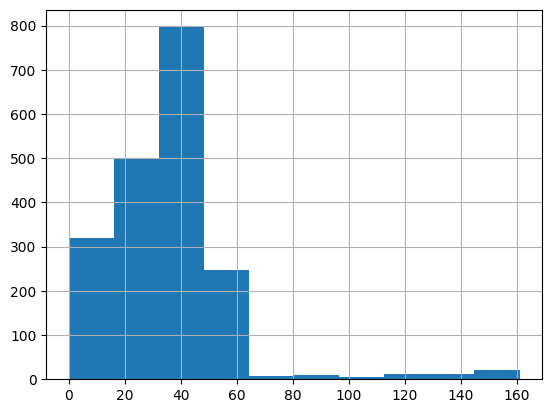

In [23]:
popular_items = df.item_id.value_counts()[:300].index.tolist()
sampled_id = np.random.choice(popular_items)

# это для примера, хотя выцеплять случаи по одному может быть не лучшей идеей
sampled_id = 3402

interactions = df.loc[df.item_id==sampled_id].copy()
name = items.loc[items.item_id==sampled_id].title.values[0]
print(name)
interactions.last_watch_dt.hist()

Фильм 1917 какое-то время набирал популярность, потом видим резкое падение (кстати, с какой даты?). Возможно, это связано с ограничением доступности этого фильма для части пользователей, периодом проката фильма / рекламной кампании или другой причиной.

Добавьте 5 своих примеров ниже. Опишите, как вы их искали.

In [24]:
# находим 5 различных сценариев с помощью метода класстеризации временных рядов
from sklearn.cluster import KMeans

df['last_watch_dt'] = pd.to_datetime(df['last_watch_dt'])

popular_items = df.item_id.value_counts().head(50).index.tolist()

max_length = 100
time_series = []

for item_id in popular_items:
    daily_counts = df[df.item_id == item_id].groupby('last_watch_dt').size()
    series = daily_counts.tail(max_length).values
    if len(series) < max_length:
        padded = np.zeros(max_length)
        padded[-len(series):] = series
    else:
        padded = series[-max_length:]

    time_series.append(padded)

days_back = np.arange(100)[::-1]
weights = np.exp(-days_back / 30)
ts_matrix = np.array(time_series)
ts_weighted = ts_matrix * weights[None, :]
ts_normalized = (ts_weighted - ts_weighted.mean(axis=1, keepdims=True)) / (ts_weighted.std(axis=1, keepdims=True) + 1e-8)

# KMeans кластеризация
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
clusters = kmeans.fit_predict(ts_normalized)

print(f"Кластеризовано {len(popular_items)} айтемов в 5 кластеров:")
for i in range(5):
    cluster_items = [popular_items[j] for j in range(len(clusters)) if clusters[j] == i]
    if cluster_items:
        first_item = cluster_items[0]
        name = items.loc[items.item_id == first_item, 'title'].iloc[0]
        print(f"Кластер {i}: {len(cluster_items)} айтемов, пример: {name[:40]}... (id={first_item})")


Кластеризовано 50 айтемов в 5 кластеров:
Кластер 0: 8 айтемов, пример: Подслушано... (id=2657)
Кластер 1: 3 айтемов, пример: Сахаров. Две жизни... (id=4740)
Кластер 2: 11 айтемов, пример: Клиника счастья... (id=15297)
Кластер 3: 24 айтемов, пример: Хрустальный... (id=10440)
Кластер 4: 4 айтемов, пример: 2067: Петля времени... (id=4457)


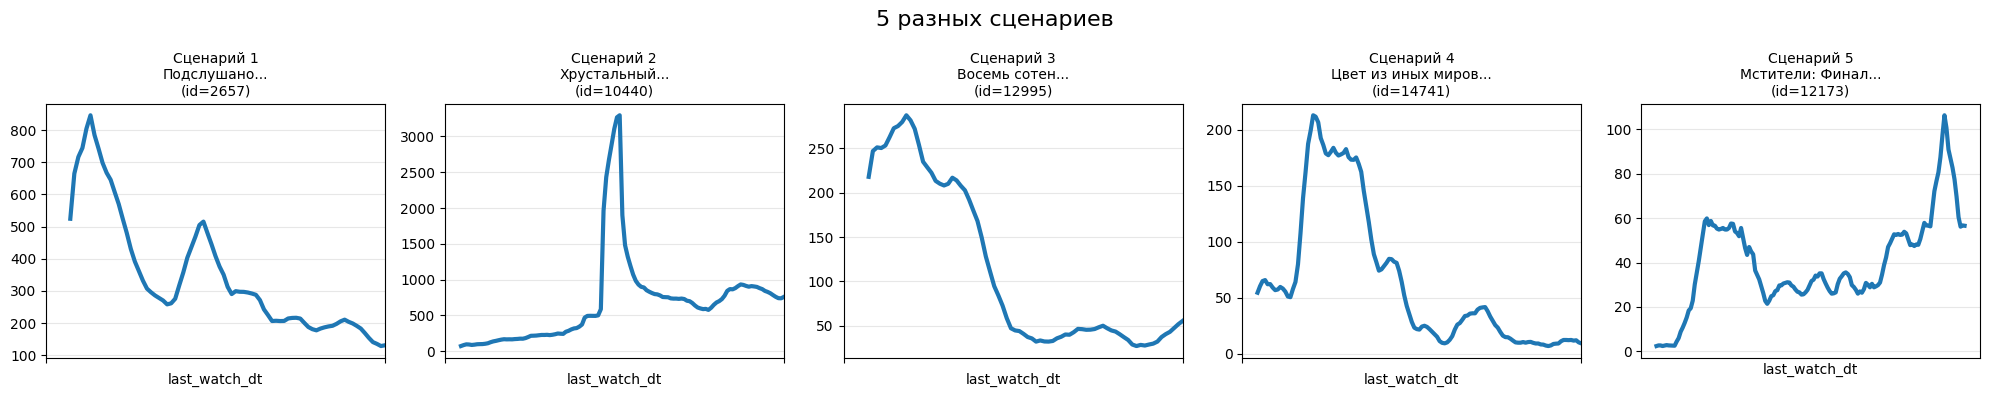

In [25]:
pattern_items = [2657, 10440, 12995, 14741, 12173]

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, item_id in enumerate(pattern_items):
    ax = axes[i]
    name = items.loc[items.item_id == item_id, 'title'].iloc[0]

    interactions = df[df.item_id == item_id].groupby('last_watch_dt').size()
    interactions.rolling(7).mean().plot(ax=ax, linewidth=3)

    ax.set_title(f"Сценарий {i+1}\n{name[:30]}...\n(id={item_id})", fontsize=10)
    ax.grid(True, alpha=0.3)

plt.suptitle('5 разных сценариев', fontsize=16)
plt.tight_layout()
plt.show()

Сценарий 1 ("Подслушано") - Угасающий хит. График начинается с высоких значений, затем идет резкий спад, небольшой "отскок" и дальнейшее плавное снижение.  Это типичный жизненный цикл популярного фильма, который был добавлен в каталог незадолго до начала сбора данных. Второй пик возможно связан с выходом новой серии.

Сценарий 2 ("Хрустальный") - Взрывной рост и резкий спад.  Долгое время активность почти нулевая, затем происходит резкий вертикальный взлет, за которым следует быстрый спад.

Сценарий 3 ("Восемь сотен") - Быстрое выгорание. Высокий старт (как у сценария 1), но спад происходит не плавно, а обрывисто, и интерес падает практически до нуля, не формируя "длинный хвост". По сути представляет собой фильм, который все хотели посмотреть здесь и сейчас, но аудитория быстро исчерпалась. Либо возможно контент убрали из рекомендательных каруселей.

Сценарий 4 ("Цвет из иных миров") - бал резкий рост, затем длительное время находился на пике, а потом постепенное снижение с периодическими пиками. Похоже на Паттерн 2, но рост чуть более плавный, а спад не такой катастрофический. Это здоровая динамика для "средненького" фильма. По сути получается, что фильм добавили, его посмотрели, интерес угас, осталось немного просмотров.

Сценарий 5 ("Мстители. Финал") - Возрождение/Сезонность. Умеренный интерес, который колеблется, а в самом конце графика виден резкий взлет, превышающий предыдущие значения. Это "старый" хит, к которому вернулся интерес из-за внешнего события. Скорее всего, это связано с выходом новой части или другого связанного контента. Люди решили пересмотреть предыдущую часть перед походом в кино на новинку.


Кластеризация временных рядов хорошо подходит для поиска сценариев популярности, так как сохраняет динамику просмотров во времени и автоматически группирует айтемы по сходным формам кривых. А также этоь метод учитывает последовательность событий и их временное положение.


**Задание №5. User-item encoding**

Теперь, создайте матрицу интеракций user-item по примеру из семинара. Вам нужно в итоге получить разреженную матрицу (sparse matrix), в которой в качестве строк будут пользователи, в качестве колонок - айтемы. Не забудьте перекодировать пользователей и айтемы через энкодер. В отличие от семинара, оставьте в матрице только юзеров и айтемы, которые встречались в матрице > 4 раз.

Важно: когда вы отфильтруете юзеров на встречаемость > 4 раз, вы удалите какие-то айтемы, которые теперь станут встречаться меньше 5 раз. Поэтому у вас перестанет выполняться второе условие на минимальное число интеракций с айтемом. Тогда вам надо опять отфильтровать айтемы на встречаемость, но это снова может нарушить условие для юзеров. В таком случае, вам надо написать итеративный алгоритм до сходимости, пока требования не будут выполняться в обеих колонках.

In [51]:
def filter_column(df, min_freq):
    """
    Filter dataframe, excluding least active users and least popular items.
    Return a copy of the dataframe with at least min_freq entries
    in both users and items
    """
    df = df.copy()

    while True:
        user_counts = df['user_id'].value_counts()
        item_counts = df['item_id'].value_counts()

        valid_users = user_counts[user_counts >= min_freq].index
        valid_items = item_counts[item_counts >= min_freq].index

        new_df = df[df ['user_id'].isin(valid_users) &
                   df['item_id'].isin(valid_items)]

        if len(new_df) == len(df):
            return new_df

        df = new_df


def filter_dataframe(df, cols, min_freq=5):
    """
    Filter dataframe by given columns until each of them satisfies
    min_freq condition, guaranteed by filter_columns. Return a copy
    of the dataframe
    """
    df = df.copy()

    while True:
        old_len = len(df)
        df = filter_column(df, min_freq)
        if len(df) == old_len:
            break

    return df

filtered_train = filter_dataframe( train_df , cols=['user_id', 'item_id'], min_freq=5)
print(f" Shape после фильтрации: {filtered_train.shape}")
print(f"Users: {filtered_train['user_id'].nunique()}")
print(f"Items: {filtered_train['item_id'].nunique()}")

 Shape после фильтрации: (105489, 5)
Users: 5858
Items: 3079


In [60]:
def df_encode(df):
    item2id = {k:v for v, k in enumerate(df.item_id.unique())}
    user2id = {k:v for v, k in enumerate(df.user_id.unique())}

    id2item = {k:v for v, k in item2id.items()}
    id2user = {k:v for v, k in user2id.items()}

    df['user_id'] = df.user_id.apply(lambda x: user2id[x])
    df['item_id'] = df.item_id.apply(lambda x: item2id[x])
    return df, id2item, id2user, item2id, user2id

filtered_train, id2item, id2user, item2id, user2id = df_encode(filtered_train)
filtered_train.sample(5)

,user_id,item_id,last_watch_dt,total_dur,watched_pct
540450,4147,35,138,470,8.0
4871424,4053,3004,134,663,10.0
3879542,743,643,126,1138,14.0
2590747,3075,206,108,17328,38.0
2312602,554,377,128,8832,100.0


In [61]:
from scipy import sparse as sps

matrix = sps.coo_matrix(
    (np.ones(filtered_train.shape[0]), (filtered_train['user_id'], filtered_train['item_id'])),
    shape=(len(user2id), len(item2id)),
)
matrix

<COOrdinate sparse matrix of dtype 'float64'
	with 105489 stored elements and shape (5858, 3079)>

**Задание №6. Интеракции и частота**

Постройте график зависимости количества айтемов и юзеров от значений (порогов) фильтров на встречаемость в матрице интеракций. То есть, нужно выполнить задание №5 для нескольких значений `min_freq` и построить график зависимости числа оставшихся айтемов и юзеров от этого параметра.

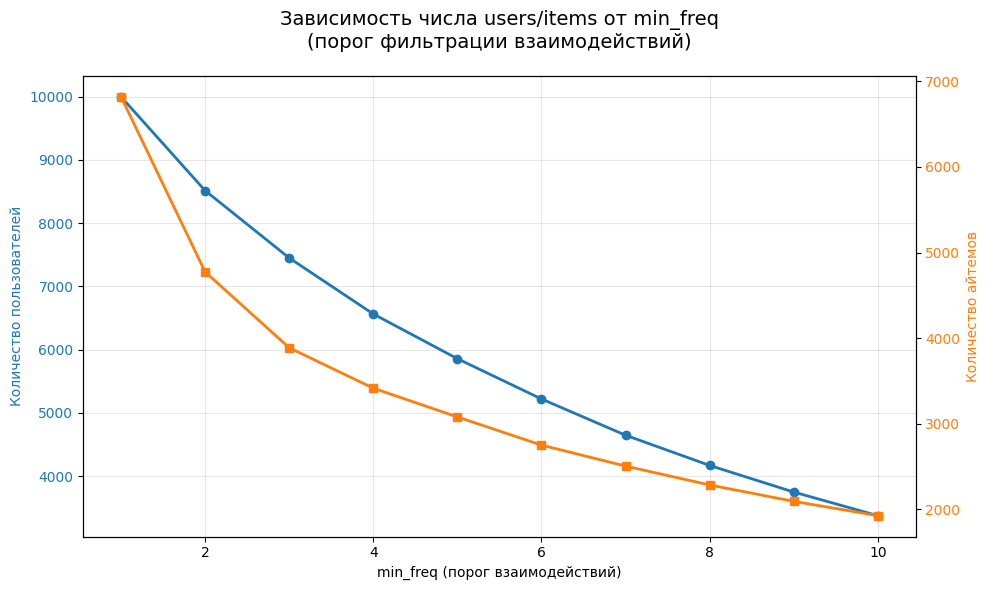

In [62]:
min_freq_values = range(1, 11)
users_count = []
items_count = []

for min_freq in min_freq_values:
    filtered = filter_dataframe(train_df, cols=['user_id', 'item_id'], min_freq=min_freq)

    n_users = filtered['user_id'].nunique()
    n_items = filtered['item_id'].nunique()

    users_count.append(n_users)
    items_count.append(n_items)


# График
fig, ax1 = plt.subplots(figsize=(10, 6))

color = 'tab:blue'
ax1.set_xlabel('min_freq (порог взаимодействий)')
ax1.set_ylabel('Количество пользователей', color=color)
ax1.plot(min_freq_values, users_count, 'o-', color=color, linewidth=2, markersize=6, label='Users')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
color = 'tab:orange'
ax2.set_ylabel('Количество айтемов', color=color)
ax2.plot(min_freq_values, items_count, 's-', color=color, linewidth=2, markersize=6, label='Items')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Зависимость числа users/items от min_freq\n(порог фильтрации взаимодействий)', fontsize=14, pad=20)
fig.tight_layout()
plt.show()

**Задание №7. EASE**

Реализуйте EASE, постройте рекомендации для юзеров. Сравните все имплементированные ранее метрики качества с `TopPopular` для некоторого набора k.

Реализацию можно взять из семинара. Можно реализовать по статье https://arxiv.org/pdf/1905.03375.pdf. Можно взять и адаптировать из RecBole https://github.com/RUCAIBox/RecBole.

In [63]:
%%time

# Обучаем конечную модель
# Мы взяли реализацию из RecBole
#
def fit_ease(X, reg_weight=1000):

    X = X.tocsr()
    n_items = X.shape[1]
    G = X.T @ X
    G = G.toarray()
    np.fill_diagonal(G, G.diagonal() + reg_weight)
    B = np.linalg.pinv(G)
    B[np.triu_indices(n_items)] = 0
    np.fill_diagonal(B, 0)

    return B

w = fit_ease(matrix)
w.shape

CPU times: user 30.2 s, sys: 1.64 s, total: 31.8 s
Wall time: 17.5 s


(3079, 3079)

Далее, вам надо реализовать функцию получения предсказаний. У вас есть обученная матрица весов, которую можно использовать для получения предсказаний. Для этого нужно построить вектор интеракций пользователя и умножить его на матрицу весов.

In [71]:
def get_preds(x, item2id, id2item, topn):

    user_items = [t[0] for t in x]
    encoded = [item2id[t] for t in user_items if t in item2id]

    vector = np.zeros(len(item2id))
    vector[encoded] = 1

    vector = sps.csr_matrix(vector)

    preds = np.array(vector.dot(w))[0]
    preds[encoded==1] = -np.inf

    ranks = np.argsort(-preds).astype(int)
    decoded = [id2item[t] for t in ranks][:topn]

    return decoded


joined['ease_preds'] = joined.train_interactions.apply(lambda x: get_preds(x, item2id, id2item, 10))
joined.head()

,user_id,train_interactions,test_interactions,random_recs,toppopular_recs,toppop_w1_recs,toppop_w2_recs,toppop_w3_recs,toppop_w4_recs,toppop_w5_recs,...,toppop_w8_recs,toppop_w9_recs,toppop_w10_recs,toppop_w11_recs,toppop_w12_recs,toppop_w13_recs,toppop_w14_recs,toppop_w15_recs,toppopular_recs_100,ease_preds
0,75,"[(11237, 20)]","[(4151, 158), (15297, 158)]","[10029, 8821, 1068]","[10440, 9728, 15297, 13865, 3734, 4151, 4880, ...","[10440, 15297, 9728, 13865, 4151, 3734, 12192,...","[10440, 15297, 9728, 13865, 4151, 3734, 12192,...","[10440, 15297, 9728, 13865, 3734, 4151, 12192,...","[10440, 15297, 9728, 13865, 3734, 4151, 12192,...","[10440, 15297, 9728, 13865, 3734, 4151, 2657, ...",...,"[10440, 9728, 15297, 13865, 3734, 4151, 2657, ...","[10440, 9728, 15297, 13865, 3734, 4151, 2657, ...","[10440, 9728, 15297, 13865, 3734, 4151, 2657, ...","[10440, 9728, 15297, 13865, 3734, 4151, 2657, ...","[10440, 9728, 15297, 13865, 3734, 4151, 2657, ...","[10440, 9728, 15297, 13865, 3734, 4151, 2657, ...","[10440, 9728, 15297, 13865, 3734, 4151, 2657, ...","[10440, 9728, 15297, 13865, 3734, 4151, 2657, ...","[10440, 9728, 15297, 13865, 3734, 4151, 4880, ...","[3071, 3070, 3069, 3068, 3067, 3066, 3065, 306..."
1,106,"[(312, 35), (3182, 58), (4718, 78), (6809, 87)...","[(14619, 162)]","[10029, 8821, 1068]","[10440, 9728, 15297, 13865, 3734, 4151, 4880, ...","[10440, 15297, 9728, 13865, 4151, 3734, 12192,...","[10440, 15297, 9728, 13865, 4151, 3734, 12192,...","[10440, 15297, 9728, 13865, 3734, 4151, 12192,...","[10440, 15297, 9728, 13865, 3734, 4151, 12192,...","[10440, 15297, 9728, 13865, 3734, 4151, 2657, ...",...,"[10440, 9728, 15297, 13865, 3734, 4151, 2657, ...","[10440, 9728, 15297, 13865, 3734, 4151, 2657, ...","[10440, 9728, 15297, 13865, 3734, 4151, 2657, ...","[10440, 9728, 15297, 13865, 3734, 4151, 2657, ...","[10440, 9728, 15297, 13865, 3734, 4151, 2657, ...","[10440, 9728, 15297, 13865, 3734, 4151, 2657, ...","[10440, 9728, 15297, 13865, 3734, 4151, 2657, ...","[10440, 9728, 15297, 13865, 3734, 4151, 2657, ...","[10440, 9728, 15297, 13865, 3734, 4151, 4880, ...","[32, 265, 120, 8, 1, 124, 266, 48, 202, 44]"
2,304,"[(11985, 71), (4457, 99), (9728, 125)]","[(6054, 161)]","[10029, 8821, 1068]","[10440, 9728, 15297, 13865, 3734, 4151, 4880, ...","[10440, 15297, 9728, 13865, 4151, 3734, 12192,...","[10440, 15297, 9728, 13865, 4151, 3734, 12192,...","[10440, 15297, 9728, 13865, 3734, 4151, 12192,...","[10440, 15297, 9728, 13865, 3734, 4151, 12192,...","[10440, 15297, 9728, 13865, 3734, 4151, 2657, ...",...,"[10440, 9728, 15297, 13865, 3734, 4151, 2657, ...","[10440, 9728, 15297, 13865, 3734, 4151, 2657, ...","[10440, 9728, 15297, 13865, 3734, 4151, 2657, ...","[10440, 9728, 15297, 13865, 3734, 4151, 2657, ...","[10440, 9728, 15297, 13865, 3734, 4151, 2657, ...","[10440, 9728, 15297, 13865, 3734, 4151, 2657, ...","[10440, 9728, 15297, 13865, 3734, 4151, 2657, ...","[10440, 9728, 15297, 13865, 3734, 4151, 2657, ...","[10440, 9728, 15297, 13865, 3734, 4151, 4880, ...","[3071, 3070, 3069, 3068, 3067, 3066, 3065, 306..."
3,522,"[(12501, 14), (2424, 15), (12254, 15)]","[(11756, 155), (4201, 159), (11899, 159)]","[10029, 8821, 1068]","[10440, 9728, 15297, 13865, 3734, 4151, 4880, ...","[10440, 15297, 9728, 13865, 4151, 3734, 12192,...","[10440, 15297, 9728, 13865, 4151, 3734, 12192,...","[10440, 15297, 9728, 13865, 3734, 4151, 12192,...","[10440, 15297, 9728, 13865, 3734, 4151, 12192,...","[10440, 15297, 9728, 13865, 3734, 4151, 2657, ...",...,"[10440, 9728, 15297, 13865, 3734, 4151, 2657, ...","[10440, 9728, 15297, 13865, 3734, 4151, 2657, ...","[10440, 9728, 15297, 13865, 3734, 4151, 2657, ...","[10440, 9728, 15297, 13865, 3734, 4151, 2657, ...","[10440, 9728, 15297, 13865, 3734, 4151, 2657, ...","[10440, 9728, 15297, 13865, 3734, 4151, 2657, ...","[10440, 9728, 15297, 13865, 3734, 4151, 2657, ...","[10440, 9728, 15297, 13865, 3734, 4151, 2657, ...","[10440, 9728, 15297, 13865, 3734, 4151, 4880, ...","[60, 2, 444, 667, 96, 44, 84, 236, 

In [77]:
def safe_evaluate_recommender(df, model_preds_col, gt_col='test_interactions', top_k=10):
    map_scores, mrr_scores, hr_scores = [], [], []

    for idx, row in df.iterrows():
        gt_items = [item for item, _ in row[gt_col]]

        recs = row[model_preds_col]
        if isinstance(recs, list) and len(recs) > 0:
            if isinstance(recs[0], tuple):
                predictions = [item for item, score in recs[:top_k]]
            else:
                predictions = recs[:top_k]
        else:
            predictions = []

        map_scores.append(ap_metric(gt_items, predictions))
        mrr_scores.append(rr_metric(gt_items, predictions))
        hr_scores.append(hr_metric(gt_items, predictions))

    return {
        f'MAP@{top_k}': np.mean(map_scores),
        f'MRR@{top_k}': np.mean(mrr_scores),
        f'HR@{top_k}': np.mean(hr_scores)
    }

toppop_metrics = safe_evaluate_recommender(joined, 'toppopular_recs')
ease_metrics = safe_evaluate_recommender(joined, 'ease_preds')

print(f"Метрики K=10:")
print(f"{'Метрика':<12} {'TopPopular':<12} {'EASE':<12}")
for metric in ['MAP@10', 'MRR@10', 'HR@10']:
    tp_val = toppop_metrics[metric]
    ease_val = ease_metrics[metric]
    print(f"{metric:<12} {tp_val:<11.4f} {ease_val:<11.4f}")

Метрики K=10:
Метрика      TopPopular   EASE        
MAP@10       0.0534      0.0003     
MRR@10       0.0782      0.0004     
HR@10        0.2091      0.0009     


Сделайте выводы — какой алгоритм работает лучше?

**Ответ:**

TopPopular работает лучше.

Тестовые взаимодействия (test_interactions) содержат много популярных items, соответственно TopPopular ранжирует именно по популярности и попадает в цель.

EASE не персонализирует: рекомендации похожи между пользователями, матрица получилась очень разреженная и ease плохо работает на таких данных. Плюс reg_weight=1000 может быть неоптимальным.


**Задание №8. Тюнинг**

Переберите различные значения гиперпараметра коэффициента регуляризации у EASE и постройте графики, как в задании №6. Постарайтесь "затюнить" EASE как можно лучше. Возьмите разумное число гиперпараметров - хотя бы штук 20 по логарифмической сетке, либо используйте более хитрые алгоритмы оптимизации.

In [81]:
reg_weights = np.logspace(-1, 3, 20).tolist() + [5, 10, 20, 50, 100, 200, 500]
reg_weights = sorted(list(set(reg_weights)))
print(f"Тестируем {len(reg_weights)} значений reg_weight: {reg_weights[:5]}...{reg_weights[-5:]}")

tune_results = {'reg_weight': [], 'MAP': [], 'MRR': [], 'HR': []}

for reg in tqdm(reg_weights, desc="EASE tuning"):
    w_reg = fit_ease(matrix, reg_weight=reg)

    def predictor_reg(x):
        def get_preds_local(x_local, item2id_local, id2item_local, topn_local):
            user_items = [t[0] for t in x_local]
            encoded = [item2id[t] for t in user_items if t in item2id]
            vector = np.zeros(len(item2id))
            vector[encoded] = 1
            vector = sps.csr_matrix(vector)
            preds = np.array(vector.dot(w_reg))[0]
            preds[encoded==1] = -np.inf
            ranks = np.argsort(-preds).astype(int)
            decoded = [id2item[t] for t in ranks][:topn_local]
            return decoded
        return get_preds_local(x, item2id, id2item, 10)

    joined[f'ease_reg_{reg:.1f}'] = joined.train_interactions.apply(predictor_reg)

    metrics = safe_evaluate_recommender(joined, f'ease_reg_{reg:.1f}')

    tune_results['reg_weight'].append(reg)
    tune_results['MAP'].append(metrics['MAP@10'])
    tune_results['MRR'].append(metrics['MRR@10'])
    tune_results['HR'].append(metrics['HR@10'])

    joined.drop(f'ease_reg_{reg:.1f}', axis=1, inplace=True)

tune_df = pd.DataFrame(tune_results)
tune_df['reg_weight_log'] = np.log10(tune_df['reg_weight'])


Тестируем 27 значений reg_weight: [0.1, 0.16237767391887217, 0.26366508987303583, 0.42813323987193935, 0.6951927961775606]...[233.57214690901213, 379.2690190732246, 500, 615.8482110660261, 1000.0]


EASE tuning: 100%|██████████| 27/27 [12:03<00:00, 26.78s/it]


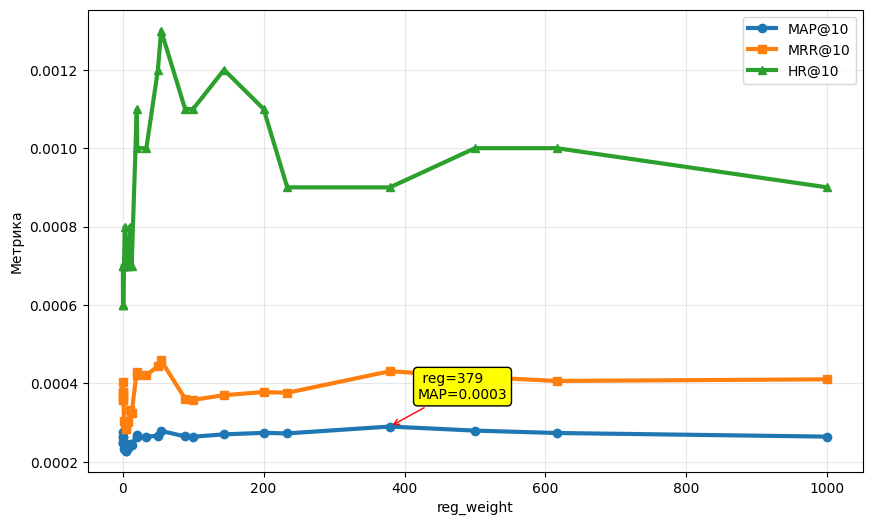

In [86]:
plt.figure(figsize=(10, 6))
plt.plot(tune_df.reg_weight, tune_df.MAP, 'o-', linewidth=3, label='MAP@10')
plt.plot(tune_df.reg_weight, tune_df.MRR, 's-', linewidth=3, label='MRR@10')
plt.plot(tune_df.reg_weight, tune_df.HR, '^-', linewidth=3, label='HR@10')

best = tune_df.loc[tune_df.MAP.idxmax()]
plt.annotate(f' reg={best.reg_weight:.0f}\nMAP={best.MAP:.4f}',
             xy=(best.reg_weight, best.MAP),
             xytext=(20, 20), textcoords='offset points',
             bbox=dict(boxstyle='round', facecolor='yellow'),
             arrowprops=dict(arrowstyle='->', color='red'))

plt.xlabel('reg_weight')
plt.ylabel('Метрика')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()



Ответьте на следующие вопросы:

8.1 Какое значение гиперпараметра является наилучшим?

**Ответ:** Наилучшим оказался гиперпараметр reg_weight = 379.

8.2 Что еще интересного вы можете сказать по графикам? Может быть, что-то свзяанное с распределением параметров, влиянием на отдельные метрики, скоростью тюнинга?

**Ответ:**

1. Влияние гиперпараметра reg_weight(L2-регуляризация)

* Слишком малый reg_weight: Модель переобучается под шум и рекомендации становятся хаотичными.
 * Слишком большой reg_weight: Все веса B стремятся к нулю, но делают это неравномерно. Модель начинает выдавать просто самые популярные товары для всех.

2. Скорость тюнинга около 10 минут.

**Задание №9. EASE и topk**

В лекции №2 говорилось, что качество у EASE растет с ослаблением фильтра на число айтемов. В этом задании постройте кривые метрик качества MAP/MRR/HR в зависимости от topk (например, от 1 до 100 с некоторым шагом), где кривая параметризована минимальным требуемым значением встречаемости user/item (из задания №6). Опишите свои выводы.

Важно: в этом задании линии могут быть мало различимыми, поэтому ваша задача для каждой метрики найти нужный масштаб на каких-то конкретных topk, чтобы линии стали визуально отличимы.

In [91]:
joined_2 = joined.copy()
results = []

for min_freq in min_freq_val:

    filtered_train = filter_dataframe(train_df_2, ['user_id', 'item_id'], min_freq=min_freq)
    filtered_train, id2item, id2user, item2id, user2id = df_encode(filtered_train)

    matrix = sps.coo_matrix(
        (np.ones(filtered_train.shape[0]),
         (filtered_train['user_id'], filtered_train['item_id'])),
        shape=(len(user2id), len(item2id))
    )

    w = fit_ease(matrix)

    def get_preds_correct(x, item2id_local, id2item_local, w, topn=100):
        try:
            n_items = w.shape[0]
            scores = np.zeros(n_items)

            interacted_items = [item for item, _ in x if item in item2id_local]
            interacted_ids = [item2id_local[item] for item in interacted_items]

            if interacted_ids:
                scores = w[interacted_ids].sum(axis=0)
                scores = np.maximum(scores, 0)
                if scores.sum() > 0:
                    scores = scores / scores.sum()

            interacted_set = set(interacted_ids)
            recs = [(id2item_local[i], float(scores[i]))
                   for i in range(n_items) if i not in interacted_set]

            return sorted(recs, key=lambda x: x[1], reverse=True)[:topn]
        except:
            return []

    joined_2['ease_preds'] = joined_2.train_interactions.apply(
        lambda x: get_preds_correct(x, item2id, id2item, w, topn=100)
    )

    for k in range(10, 101, 10):
        map_k, mrr_k, hr_k = [], [], []

        for idx, row in joined_2.iterrows():
            gt_items = [x[0] for x in row['test_interactions']]

            predictions = [item for item, _ in row['ease_preds'][:k]
                          if item in id2item.values()]

            map_k.append(ap_metric(gt_items, predictions))
            mrr_k.append(rr_metric(gt_items, predictions))
            hr_k.append(hr_metric(gt_items, predictions))

        results.append({
            "k": k,
            "map": np.mean(map_k),
            "mrr": np.mean(mrr_k),
            "hr": np.mean(hr_k),
            'min_freq': min_freq
        })

    joined_2.drop('ease_preds', axis=1, inplace=True)

results_df = pd.DataFrame(results)
results_df


min_freq = 5
min_freq = 6
min_freq = 7
min_freq = 8
min_freq = 9


,k,map,mrr,hr,min_freq
0,10,0.005410,0.009268,0.0270,5
1,20,0.006219,0.010598,0.0464,5
2,30,0.006493,0.011092,0.0588,5
3,40,0.006762,0.011519,0.0739,5
4,50,0.006927,0.011773,0.0854,5
5,60,0.007058,0.011974,0.0965,5
6,70,0.007158,0.012134,0.1069,5
7,80,0.007229,0.012250,0.1157,5
8,90,0.007342,0.012410,0.1295,5
9,100,0.007472,0.012585,0.1462,5


In [92]:
metrics_2 = pd.DataFrame(results)
metrics_2.head()

,k,map,mrr,hr,min_freq
0,10,0.005410,0.009268,0.0270,5
1,20,0.006219,0.010598,0.0464,5
2,30,0.006493,0.011092,0.0588,5
3,40,0.006762,0.011519,0.0739,5
4,50,0.006927,0.011773,0.0854,5


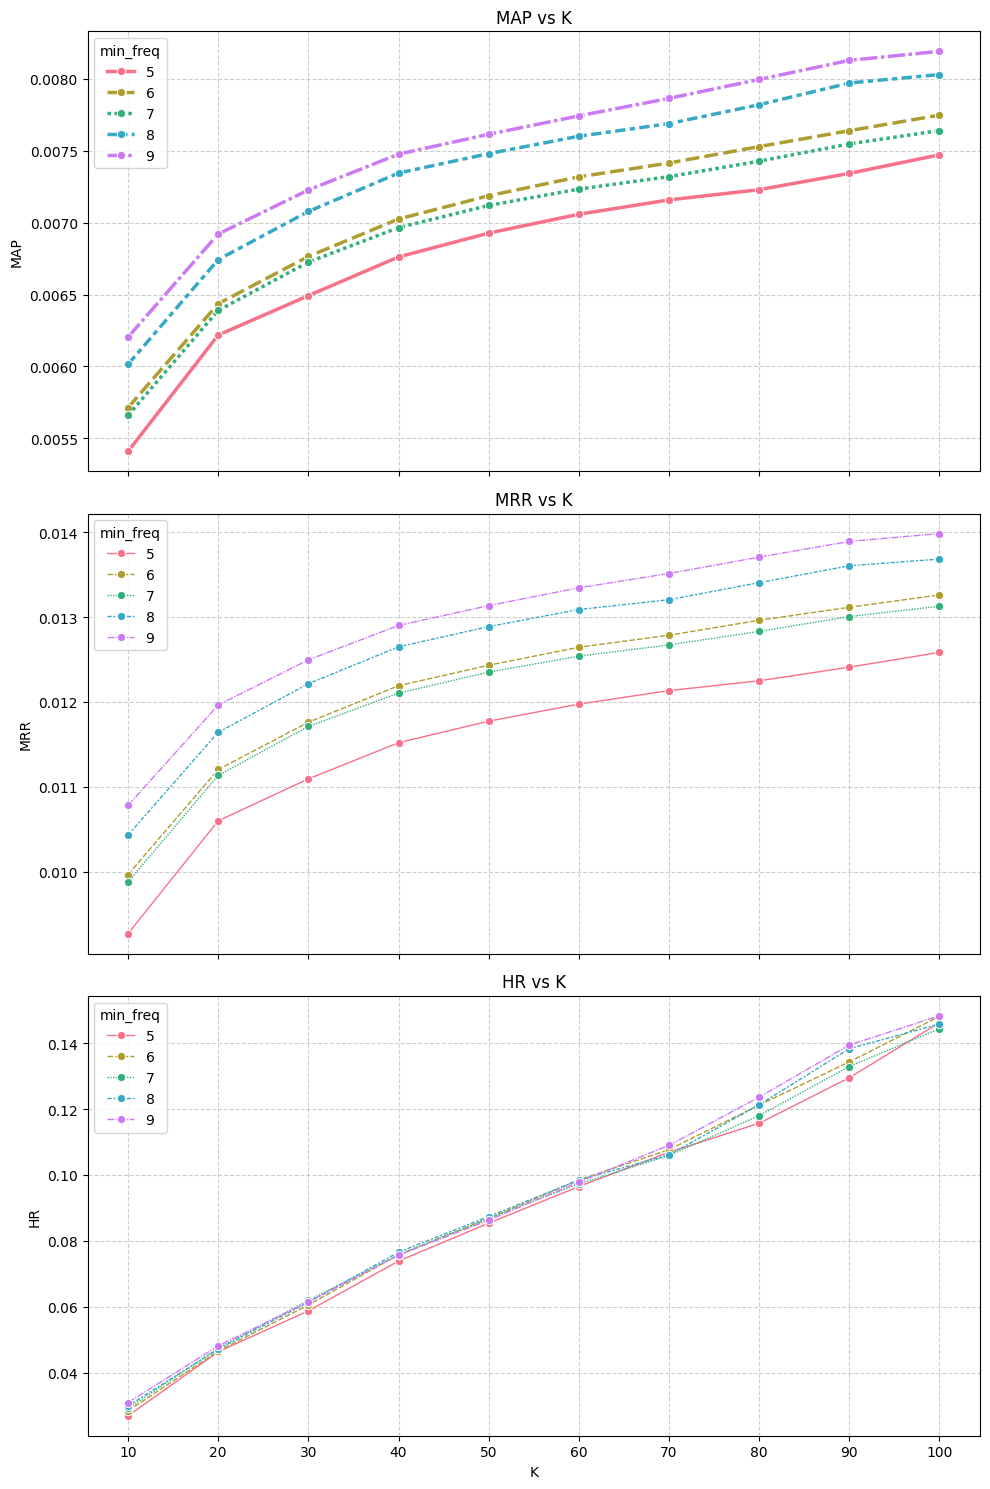

In [94]:
import seaborn as sns
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(10, 15), sharex=True)

palette = sns.color_palette("husl", len(metrics_2["min_freq"].unique()))

sns.lineplot(data=metrics_2, x="k", y="map", hue="min_freq", style="min_freq", marker="o", ax=axes[0], palette=palette, linewidth=2.5)
axes[0].set_title("MAP vs K")
axes[0].set_ylabel("MAP")

sns.lineplot(data=metrics_2, x="k", y="mrr", hue="min_freq", style="min_freq", marker="o", ax=axes[1], palette=palette, linewidth=1)
axes[1].set_title("MRR vs K")
axes[1].set_ylabel("MRR")

sns.lineplot(data=metrics_2, x="k", y="hr", hue="min_freq", style="min_freq", marker="o", ax=axes[2], palette=palette, linewidth=1)
axes[2].set_title("HR vs K")
axes[2].set_ylabel("HR")

for ax in axes:
    ax.set_xlabel("K")
    ax.legend(title="min_freq")
    ax.grid(True, linestyle="--", alpha=0.6)
    ax.set_xticks(np.arange(10, 101, 10))
plt.tight_layout()
plt.show()

Что вы можете сказать на основе полученных графиков? Соответствуют ли они вашим ожиданиям?

**Ответ:**

C увеличением TOP K метрики все растут вверх. Различия между линиями небольшие, что говорит о том, что показатель min freq не сильно влияет, но все же чем, он выше, тем лучшее значение метрики.

**Задание №10. Интерпретируемые рекомендации**

Используйте выученную матрицу весов для item2item рекомендаций. Приведите 10 примеров топ-5 рекомендаций от EASE к сэмплируемым айтемам. Используйте названия фильмов вместо id при выводе рекомендаций.

In [ ]:
# your code here

Хорошие ли получились рекомендации? Почему? Есть ли хорошие примеры? Есть ли плохие? Почему бывают плохие примеры?

**Ответ:**